# DuPont decomposition of operating ROA — Spanish non-financial corporations, 2019–2024

**Question.** Did the Spanish sectors that improved their returns between 2019 and 2024 do it by charging more (margin) or by using their assets better (asset turnover)?

**Method.** Operating ROA is split into margin × asset turnover (DuPont), and its change between 2019 and 2024 is decomposed into a margin effect, a turnover effect and their interaction.

**Data.** BACH database (ECCBSO), Spain, non-financial corporations by NACE section, 2018–2024, extracted on 15 September 2026. The raw file is not included in this repository, because BACH's conditions of use prohibit redistribution. The README explains how to download it.

## 1. Setup

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 88)

## 2. Load

BACH export, 15 September 2026 (`;` separator, decimal point):

- **Country:** Spain. **Years:** 2018–2025 (Spain's 2025 was not yet published, so the file ends in 2024).
- **Size classes:** all five. **Samples:** variable and sliding. **Sectors:** all NACE sections, with divisions.
- **Characteristics:** total assets, turnover, gross value added, employees and number of companies; all profitability ratios (R31–R313) and activity ratios (R41, R42), each as weighted mean, quartiles and number of companies.

In [30]:
bach_raw = pd.read_csv('../data/raw/bach/export-bach_2026-09-15-13-14-31.csv', sep=';')
bach_raw

,country,year,sector,size,sample,coverage_firms,coverage_turnover,coverage_employees,total_assets,turnover,gross_value_added,nb_firms,employees,R31_WM,R31_NBQ,R31_Q1,R31_Q2,R31_Q3,R32_WM,R32_NBQ,R32_Q1,R32_Q2,R32_Q3,R33_WM,R33_NBQ,R33_Q1,R33_Q2,R33_Q3,R34_WM,R34_NBQ,R34_Q1,R34_Q2,R34_Q3,R35_WM,R35_NBQ,R35_Q1,R35_Q2,R35_Q3,R36_WM,R36_NBQ,R36_Q1,R36_Q2,R36_Q3,R37_WM,R37_NBQ,R37_Q1,R37_Q2,R37_Q3,R38_WM,R38_NBQ,R38_Q1,R38_Q2,R38_Q3,R39_WM,R39_NBQ,R39_Q1,R39_Q2,R39_Q3,R310_WM,R310_NBQ,R310_Q1,R310_Q2,R310_Q3,R311_WM,R311_NBQ,R311_Q1,R311_Q2,R311_Q3,R312_WM,R312_NBQ,R312_Q1,R312_Q2,R312_Q3,R313_WM,R313_NBQ,R313_Q1,R313_Q2,R313_Q3,R41_WM,R41_NBQ,R41_Q1,R41_Q2,R41_Q3,R42_WM,R42_NBQ,R42_Q1,R42_Q2,R42_Q3
0,ES,2017,A,0,-1,NaN,NaN,NaN,2.966319e+07,17095787.0,4594035.0,19869,123031.0,26.87,18981,17.44,39.89,61.99,11.29,18981,1.97,11.88,28.84,11.88,18981,2.24,12.32,29.61,6.66,18981,-2.71,4.97,17.79,7.89,18981,0.49,6.57,20.44,6.91,18981,-0.04,4.86,18.23,-0.38,18981,-1.85,-0.30,0.00,5.45,17851,0.16,5.39,17.70,3.84,19869,-1.17,2.39,8.12,7.14,17851,0.25,6.89,22.74,6.85,19869,0.50,5.55,12.89,6.91,18981,-0.04,4.86,18.23,NaN,0,NaN,NaN,NaN,57.63,19869,13.30,45.06,102.92,57.99,17434,28.91,56.58,82.67
1,ES,2017,A,1,-1,NaN,NaN,NaN,2.716701e+07,13231768.0,4031002.0,19836,116255.0,30.46,18948,17.51,39.98,62.02,12.21,18948,1.97,11.89,28.87,12.88,18948,2.24,12.35,29.63,6.93,18948,-2.75,4.97,17.83,8.50,18948,0.49,6.57,20.46,7.34,18948,-0.05,4.87,18.26,-0.48,18948,-1.86,-0.30,0.00,4.78,17818,0.16,5.38,17.67,3.37,19836,-1.17,2.39,8.12,6.27,17818,0.25,6.88,22.72,6.27,19836,0.50,5.54,12.88,7.34,18948,-0.05,4.87,18.26,NaN,0,NaN,NaN,NaN,48.71,19836,13.27,44.92,102.51,59.93,17402,28.92,56.63,82.68
2,ES,2017,A,1a,-1,NaN,NaN,NaN,2.353216e+07,9423409.0,3227737.0,19631,100393.0,34.25,18744,17.84,40.38,62.23,12.93,18744,1.92,11.99,29.06,13.68,18744,2.19,12.43,29.86,6.97,18744,-2.97,4.97,17.98,8.62,18744,0.45,6.58,20.63,7.26,18744,-0.19,4.86,18.34,-0.61,18744,-1.89,-0.30,0.00,3.69,17616,0.13,5.25,17.43,2.79,19631,-1.22,2.34,8.05,5.02,17616,0.21,6.76,22.44,5.48,19631,0.45,5.47,12.80,7.26,18744,-0.19,4.86,18.34,NaN,0,NaN,NaN,NaN,40.04,19631,13.03,44.14,101.08,62.25,17201,28.99,56.79,82.87
3,ES,2017,A,1b,-1,NaN,NaN,NaN,3.634854e+06,3808358.0,803264.0,205,15861.0,21.09,204,9.17,17.99,29.61,10.42,204,3.39,8.15,14.19,10.91,204,3.52,8.43,14.73,6.81,204,1.47,4.98,9.60,8.20,204,2.29,5.67,10.98,7.54,204,1.56,5.17,10.25,-0.17,204,-0.66,-0.25,-0.05,12.79,202,7.19,16.16,26.06,7.14,205,2.62,7.30,14.72,15.51,202,8.84,20.14,33.90,11.43,205,6.45,12.04,18.32,7.54,204,1.56,5.17,10.25,NaN,0,NaN,NaN,NaN,104.77,205,91.22,140.75,222.78,50.61,201,25.05,43.01,67.22
4,ES,2017,A,2,-1,NaN,NaN,NaN,2.496183e+06,3864019.0,563033.0,33,6776.0,14.57,33,7.48,10.97,20.01,8.15,33,2.19,6.09,12.13,8.46,33,2.24,6.26,12.29,5.76,33,0.32,3.08,9.28,5.78,33,0.78,2.92,8.86,5.42,33,0.48,2.47,8.64,-0.04,33,-0.36,-0.09,0.01,15.39,33,4.05,12.80,25.03,8.92,33,0.63,6.00,13.05,19.88,33,4.94,15.79,30.04,13.10,33,5.26,11.30,16.56,5.42,33,0.48,2.47,8.64,NaN,0,NaN,NaN,NaN,154.80,33,128.79,183.87,245.83,44.09,32,26.72,44.31,76.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10495,ES,2024,Zc,1a,1,NaN,NaN,NaN,6.823794e+08,447169390.0,165937367.0,630904,3459245.0,37.11,611318,21.30,40.50,61.14,10.64,611318,1.31,7.17,19.89,11.79,611318,1.50,7.49,20.87,7.50,611318,0.00,4.63,14.92,9.58,611318,0.65,5.29,16.77,8.36,611318,0.24,4.37,15.30,-0.08,611318,-0.76,-0.07,0.00,7.24,560503,1.16,8.92,24.91,4.91,630900,-0.19,4.50,13.75,9.26,560503,1.56,11.37,31.42,7.72,630900,1.23,7.30,17.45,8.36,611318,0.24,4.37,15.30,6.37,590976,-10.04,3.66,20.96,65.53,630900,35.59,111.01,214.19,71.32,581296,40.98,74.72,92.43
10496,ES,2024,Zc,1b,0,NaN,NaN,

In [31]:
bach_raw.columns

Index(['country', 'year', 'sector', 'size', 'sample', 'coverage_firms',
       'coverage_turnover', 'coverage_employees', 'total_assets', 'turnover',
       'gross_value_added', 'nb_firms', 'employees', 'R31_WM', 'R31_NBQ',
       'R31_Q1', 'R31_Q2', 'R31_Q3', 'R32_WM', 'R32_NBQ', 'R32_Q1', 'R32_Q2',
       'R32_Q3', 'R33_WM', 'R33_NBQ', 'R33_Q1', 'R33_Q2', 'R33_Q3', 'R34_WM',
       'R34_NBQ', 'R34_Q1', 'R34_Q2', 'R34_Q3', 'R35_WM', 'R35_NBQ', 'R35_Q1',
       'R35_Q2', 'R35_Q3', 'R36_WM', 'R36_NBQ', 'R36_Q1', 'R36_Q2', 'R36_Q3',
       'R37_WM', 'R37_NBQ', 'R37_Q1', 'R37_Q2', 'R37_Q3', 'R38_WM', 'R38_NBQ',
       'R38_Q1', 'R38_Q2', 'R38_Q3', 'R39_WM', 'R39_NBQ', 'R39_Q1', 'R39_Q2',
       'R39_Q3', 'R310_WM', 'R310_NBQ', 'R310_Q1', 'R310_Q2', 'R310_Q3',
       'R311_WM', 'R311_NBQ', 'R311_Q1', 'R311_Q2', 'R311_Q3', 'R312_WM',
       'R312_NBQ', 'R312_Q1', 'R312_Q2', 'R312_Q3', 'R313_WM', 'R313_NBQ',
       'R313_Q1', 'R313_Q2', 'R313_Q3', 'R41_WM', 'R41_NBQ', 'R41_Q1',
       'R41_Q

## 3. Filter

**Filter: one sample and one size level.**

- `sample = 0` — variable sample: every company with a balance sheet that year.
- `size = '0'` — all size classes combined. The other size rows overlap with it, so keeping them would double-count companies.
- BACH's sample covers 49% of Spanish non-financial companies and 68% of their employment (2024).

In [32]:
bach_all_sizes = bach_raw[(bach_raw['sample'] == 0) & (bach_raw['size'] == '0')]
bach_all_sizes

,country,year,sector,size,sample,coverage_firms,coverage_turnover,coverage_employees,total_assets,turnover,gross_value_added,nb_firms,employees,R31_WM,R31_NBQ,R31_Q1,R31_Q2,R31_Q3,R32_WM,R32_NBQ,R32_Q1,R32_Q2,R32_Q3,R33_WM,R33_NBQ,R33_Q1,R33_Q2,R33_Q3,R34_WM,R34_NBQ,R34_Q1,R34_Q2,R34_Q3,R35_WM,R35_NBQ,R35_Q1,R35_Q2,R35_Q3,R36_WM,R36_NBQ,R36_Q1,R36_Q2,R36_Q3,R37_WM,R37_NBQ,R37_Q1,R37_Q2,R37_Q3,R38_WM,R38_NBQ,R38_Q1,R38_Q2,R38_Q3,R39_WM,R39_NBQ,R39_Q1,R39_Q2,R39_Q3,R310_WM,R310_NBQ,R310_Q1,R310_Q2,R310_Q3,R311_WM,R311_NBQ,R311_Q1,R311_Q2,R311_Q3,R312_WM,R312_NBQ,R312_Q1,R312_Q2,R312_Q3,R313_WM,R313_NBQ,R313_Q1,R313_Q2,R313_Q3,R41_WM,R41_NBQ,R41_Q1,R41_Q2,R41_Q3,R42_WM,R42_NBQ,R42_Q1,R42_Q2,R42_Q3
501,ES,2018,A,0,0,NaN,NaN,NaN,3.077660e+07,1.743347e+07,4527334.0,19869,127323.0,25.97,19344,17.22,39.58,61.49,10.00,19344,1.64,11.52,28.61,10.63,19344,1.91,11.86,29.35,5.25,19344,-4.04,4.49,17.13,6.56,19344,0.23,6.02,19.93,5.62,19344,-0.86,4.44,17.58,-0.31,19344,-1.82,-0.32,0.0,4.29,17912,0.18,4.84,15.65,2.97,19869,-1.35,2.19,7.42,5.66,17912,0.26,6.22,20.10,6.02,19869,0.53,5.34,12.32,5.62,19344,-0.86,4.44,17.58,NaN,18981,NaN,NaN,NaN,56.65,19869,13.88,44.77,101.27,61.50,17648,29.88,58.23,83.49
516,ES,2018,A01,0,0,NaN,NaN,NaN,2.770926e+07,1.543181e+07,3762285.0,18087,112779.0,24.38,17632,16.48,38.89,61.35,9.69,17632,1.66,11.90,29.70,10.24,17632,1.95,12.33,30.46,5.14,17632,-3.93,4.71,17.91,6.44,17632,0.29,6.38,21.00,5.50,17632,-0.66,4.66,18.45,-0.39,17632,-1.89,-0.32,0.0,4.15,16366,0.20,4.79,15.48,2.86,18087,-1.26,2.17,7.26,5.47,16366,0.29,6.16,19.87,5.70,18087,0.53,5.20,11.91,5.50,17632,-0.66,4.66,18.45,NaN,17283,NaN,NaN,NaN,55.69,18087,13.07,41.52,95.80,60.24,16044,28.14,55.83,82.11
531,ES,2018,A02,0,0,NaN,NaN,NaN,9.206690e+05,6.126520e+05,208609.0,977,6597.0,34.05,938,19.27,38.89,58.71,6.59,938,-0.17,6.57,16.68,7.13,938,0.39,6.86,17.07,1.84,938,-7.93,2.32,9.56,3.62,938,-2.47,3.15,11.54,2.71,938,-3.76,1.94,9.74,-0.37,938,-1.48,-0.43,0.0,2.34,855,-0.64,4.77,19.12,1.23,977,-3.59,1.81,8.31,3.16,855,-0.68,5.90,24.30,4.75,977,-0.40,5.60,14.38,2.71,938,-3.76,1.94,9.74,NaN,920,NaN,NaN,NaN,66.54,977,29.38,80.35,145.02,80.64,852,50.28,75.09,93.65
546,ES,2018,A03,0,0,NaN,NaN,NaN,2.146682e+06,1.389009e+06,556439.0,805,7946.0,40.06,774,36.86,53.75,65.15,14.89,774,3.00,10.98,19.37,16.47,774,3.30,11.15,19.67,7.92,774,-2.46,3.82,11.03,9.21,774,-0.73,4.60,12.62,8.29,774,-1.44,3.84,11.62,0.66,774,-0.99,-0.14,0.0,6.87,691,0.24,6.51,16.35,5.13,805,-2.15,3.48,10.50,8.88,691,0.37,8.03,21.66,10.66,805,2.18,8.97,17.66,8.29,774,-1.44,3.84,11.62,NaN,778,NaN,NaN,NaN,64.70,805,45.74,80.43,132.83,62.83,752,60.65,76.28,90.24
561,ES,2018,B,0,0,57.74,NaN,70.92,9.223636e+06,3.469015e+06,1463335.0,1197,13803.0,42.18,1141,23.23,37.77,51.19,25.01,1141,0.85,7.96,18.49,28.59,1141,1.04,8.24,18.93,13.99,1141,-4.33,3.10,10.93,16.98,1141,-2.54,4.14,12.74,14.62,1141,-3.66,2.75,10.92,1.22,1141,-1.38,-0.35,0.0,8.01,1076,-0.83,2.48,10.30,5.26,1197,-1.68,1.28,6.10,10.39,1076,-0.93,3.01,12.60,10.75,1197,-0.01,3.73,10.15,14.62,1141,-3.66,2.75,10.92,NaN,1140,NaN,NaN,NaN,37.61,1197,18.79,47.50,88.17,40.70,1072,47.31,72.69,91.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10458,ES,2024,S94,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
10468,ES,2024,S95,0,0,23.59,NaN,39.38,6.287800e+05,8.271510e+05,384242.0,1469,8529.0,46.45,1455,29.49,43.93,57.40,10.11,1455,0.41,4.60,11.75,10.60,1455,0.43,4.62,11.79,8.48,1455,-0.39,3.02,9.85,9.

In [33]:
coverage_2024 = bach_all_sizes[(bach_all_sizes['sector'] == 'Zc') & (bach_all_sizes['year'] == 2024)]

print('Share of companies covered (2024): ', coverage_2024['coverage_firms'].iloc[0], '%')
print('Share of employment covered (2024):', coverage_2024['coverage_employees'].iloc[0], '%')

Share of companies covered (2024):  49.14 %
Share of employment covered (2024): 67.92 %


**DuPont ratios, weighted mean.**

`_WM` is the weighted mean: the ratio of sector totals, not the average of company ratios. The DuPont identity only holds on this version.

| column | BACH | definition |
|---|---|---|
| `margin` | R34 | Net operating profit / Net turnover (%) |
| `asset_turnover` | R41 | Net turnover / Total assets (%) |
| `oroa` | R39 | Net operating profit / Total assets (%) |

R34 and R39 share the same numerator, which is what makes the identity close. BACH's own "EBIT" (R35) is unusable here: no EBIT / Total assets ratio exists.

In [34]:
dupont = bach_all_sizes[['year', 'sector', 'R34_WM', 'R41_WM', 'R39_WM']]

dupont = dupont.rename(columns = {'R34_WM': 'margin', 'R41_WM': 'asset_turnover', 'R39_WM': 'oroa'})

**Sector level: NACE sections only** (1-character codes).

Divisions (`A01`, `A02`...) are contained in their section, so mixing levels double-counts the same companies. K (financial), O, T and U are not published by BACH for Spain.

Section M is replaced by `Mc`, which is M without head offices (M701). Head offices hold most of M's assets but almost none of its turnover (see the next cell), so M would describe them rather than professional services. The reason is explained in section 7.

In [35]:
is_section = dupont['sector'].str.len() == 1
dupont_sections = dupont[(is_section & (dupont['sector'] != 'M')) | (dupont['sector'] == 'Mc')]

dupont_sections = dupont_sections.set_index(['sector', 'year']).sort_index()
dupont_sections.head(21)

margin  asset_turnover  oroa
sector year                              
A      2018    5.25           56.65  2.97
       2019    5.13           56.68  2.91
       2020    5.17           54.04  2.79
       2021    3.99           56.77  2.26
       2022    4.02           60.00  2.41
       2023    7.84           60.82  4.77
       2024    9.35           56.47  5.28
B      2018   13.99           37.61  5.26
       2019    8.17           33.04  2.70
       2020    7.66           30.89  2.37
       2021   15.97           34.31  5.48
       2022    6.47           32.98  2.13
       2023    5.07           39.40  2.00
       2024   11.42           37.39  4.27
C      2018    4.58          109.58  5.02
       2019    4.08          109.58  4.48
       2020    2.49           94.46  2.35
       2021    4.14          103.99  4.31
       2022    4.13          119.22  4.93
       2023    4.59          116.78  5.36
       2024    5.01          113.74  5.70

In [36]:
m_assets_2024 = (
    bach_all_sizes[(bach_all_sizes['year'] == 2024) & bach_all_sizes['sector'].isin(['M', 'M701'])]
    .set_index('sector')['total_assets']
)

print('Head offices, share of section M assets (2024):',
      round(100 * m_assets_2024['M701'] / m_assets_2024['M'], 1), '%')

Head offices, share of section M assets (2024): 87.8 %


## 4. Validation

`margin × asset_turnover / 100` must reproduce the published `oroa`. Any difference is rounding: BACH publishes ratios to 2 decimals.

In [37]:
oroa_gap_nop = (
    dupont_sections['margin']
    * dupont_sections['asset_turnover'] / 100
    - dupont_sections['oroa']
)

print('Max difference:', round(oroa_gap_nop.abs().max(), 4))
print('Empty values:', dupont_sections.isna().sum().sum())

Max difference: 0.0091
Empty values: 0


## 5. Exploration

Operating ROA per sector, 2018–2024. All panels share the same vertical scale so sectors can be compared with each other. The vertical lines mark 2019 and 2024, the two years used in the decomposition.

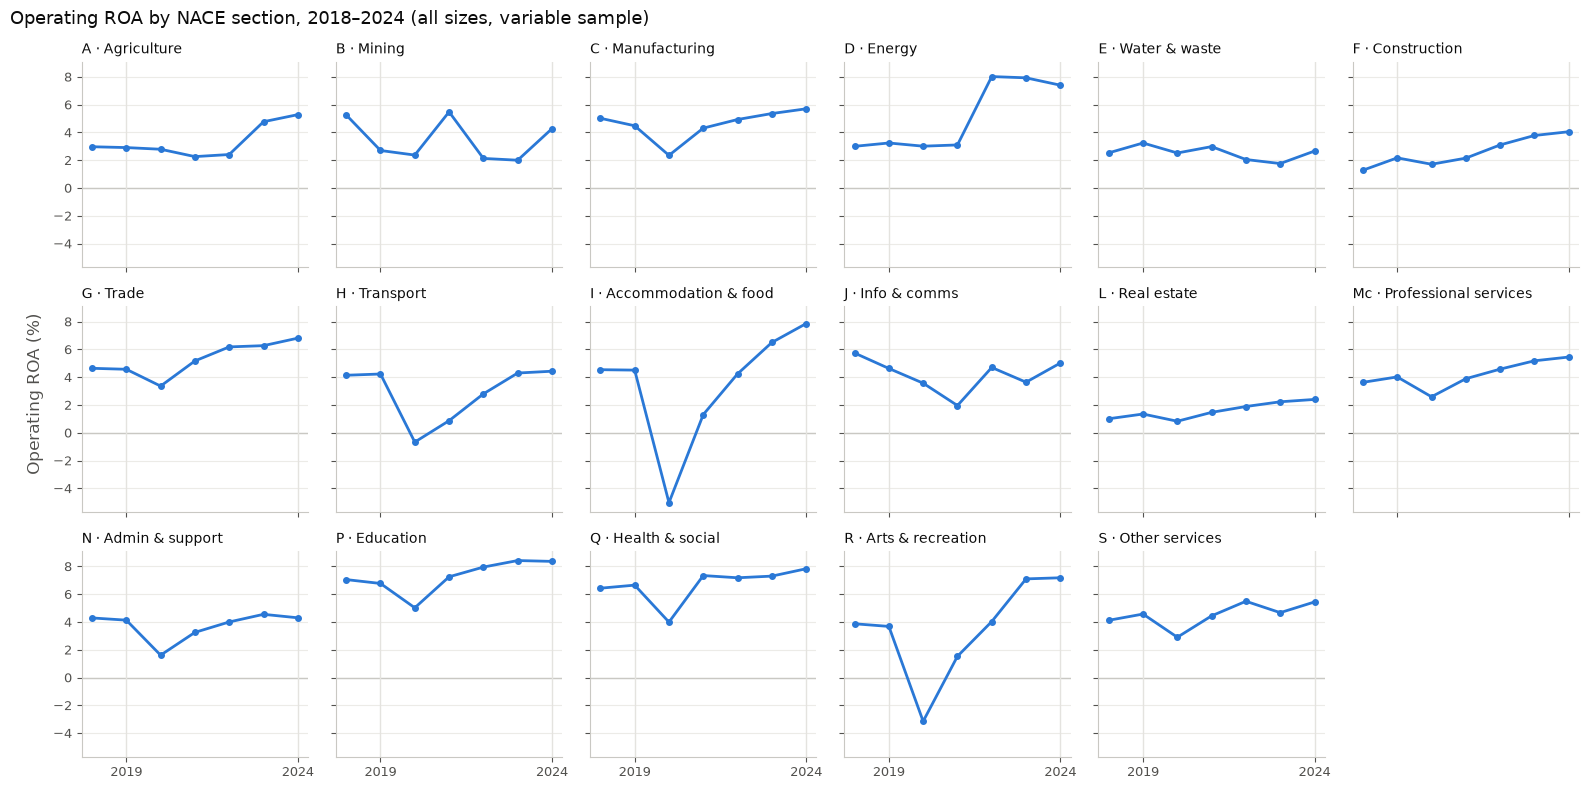

In [38]:
# Short NACE section names for chart labels
section_names = {
    'A': 'Agriculture', 'B': 'Mining', 'C': 'Manufacturing', 'D': 'Energy',
    'E': 'Water & waste', 'F': 'Construction', 'G': 'Trade', 'H': 'Transport',
    'I': 'Accommodation & food', 'J': 'Info & comms', 'L': 'Real estate',
    'Mc': 'Professional services', 'N': 'Admin & support', 'P': 'Education',
    'Q': 'Health & social', 'R': 'Arts & recreation', 'S': 'Other services',
}

# One column per sector, one row per year
oroa_by_year = dupont_sections['oroa'].unstack('sector')

fig, axes = plt.subplots(3, 6, figsize=(16, 8), sharex=True, sharey=True)

for ax, sector in zip(axes.flat, oroa_by_year.columns):
    ax.axhline(0, color='#c9c8c3', linewidth=1)
    for year in (2019, 2024):
        ax.axvline(year, color='#e4e3df', linewidth=1)
    ax.plot(oroa_by_year.index, oroa_by_year[sector],
            color='#2a78d6', linewidth=2, marker='o', markersize=4)
    ax.set_title(f'{sector} · {section_names[sector]}', fontsize=10, loc='left', color='#0b0b0b')
    ax.set_xticks([2019, 2024])
    ax.grid(axis='y', color='#ecebe7', linewidth=0.8)
    ax.tick_params(colors='#52514e', labelsize=9)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color('#c9c8c3')

# 17 sections in an 18-panel grid: hide the empty one
for ax in axes.flat[len(oroa_by_year.columns):]:
    ax.axis('off')

fig.supylabel('Operating ROA (%)', color='#52514e')
fig.suptitle('Operating ROA by NACE section, 2018–2024 (all sizes, variable sample)',
             x=0.01, ha='left', fontsize=13, color='#0b0b0b')
plt.tight_layout()
plt.show()

Structural position of each sector: asset turnover on the x-axis, margin on the y-axis. Moving up means a higher margin, moving right means more sales per euro of assets.

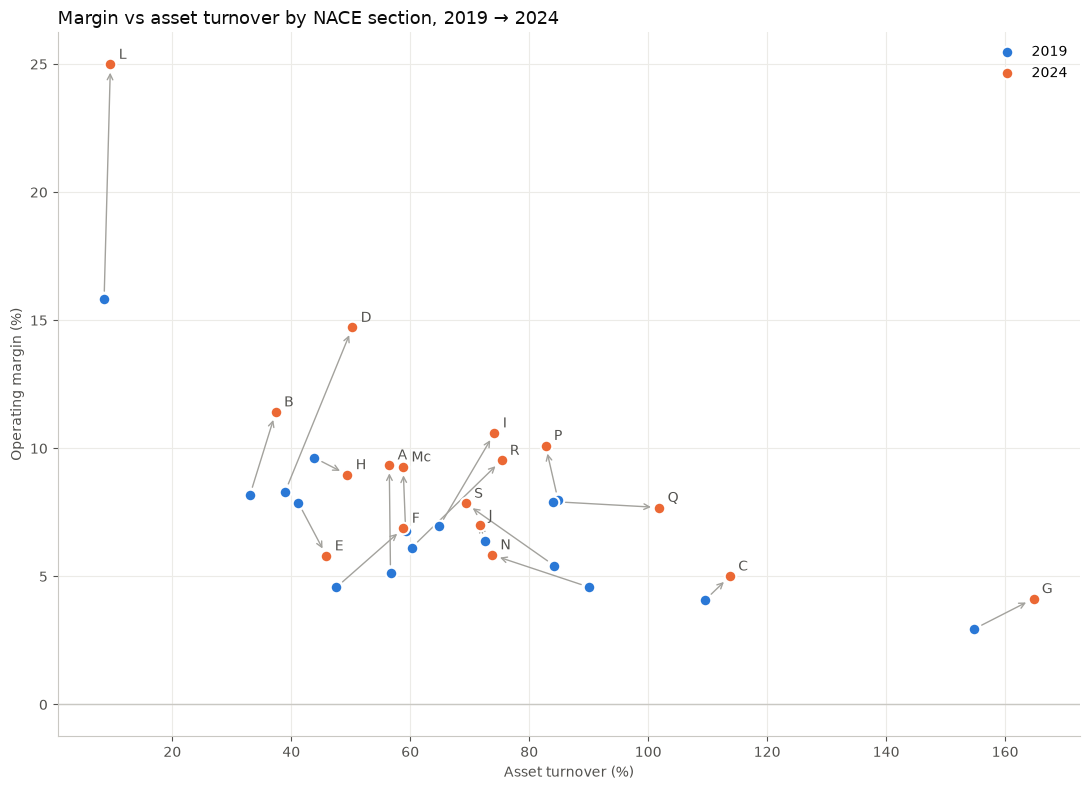

In [39]:
start = dupont_sections.xs(2019, level='year')
end = dupont_sections.xs(2024, level='year')

fig, ax = plt.subplots(figsize=(11, 8))

ax.axhline(0, color='#c9c8c3', linewidth=1)

# Arrow from 2019 to 2024 for each sector
for sector in start.index:
    ax.annotate('',
                xy=(end.loc[sector, 'asset_turnover'], end.loc[sector, 'margin']),
                xytext=(start.loc[sector, 'asset_turnover'], start.loc[sector, 'margin']),
                arrowprops=dict(arrowstyle='->', color='#a3a29d', linewidth=1,
                                shrinkA=6, shrinkB=6))

ax.scatter(start['asset_turnover'], start['margin'], s=70, color='#2a78d6',
           edgecolor='white', linewidth=1.5, zorder=3, label='2019')
ax.scatter(end['asset_turnover'], end['margin'], s=70, color='#eb6834',
           edgecolor='white', linewidth=1.5, zorder=3, label='2024')

# Sector code next to the 2024 point
for sector in end.index:
    ax.annotate(sector, (end.loc[sector, 'asset_turnover'], end.loc[sector, 'margin']),
                xytext=(6, 4), textcoords='offset points', fontsize=10, color='#52514e')

ax.set_xlabel('Asset turnover (%)', color='#52514e')
ax.set_ylabel('Operating margin (%)', color='#52514e')
ax.set_title('Margin vs asset turnover by NACE section, 2019 → 2024',
             loc='left', fontsize=13, color='#0b0b0b')
ax.grid(color='#ecebe7', linewidth=0.8)
ax.tick_params(colors='#52514e')
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color('#c9c8c3')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Decomposition

**Decomposition of the change in OROA.**

With margin *M* and asset turnover *T*, from base year 0 to end year 1:

ΔOROA = ΔM × T₀ + M₀ × ΔT + ΔM × ΔT

- `margin_effect` — change in margin, at base-year turnover.
- `turnover_effect` — change in turnover, at base-year margin.
- `interaction` — both changing at once. Shown separately, not allocated to either effect.
- `d_oroa` — total change in OROA.
- `check` — effects minus `d_oroa`. Must be 0; values like `1e-15` are floating-point zeros.
- `main_driver` — the effect with the larger absolute size.
- `interaction_share` — interaction as a share of total movement (sum of absolute effects).
- `trend` (added after the threshold below) — `up`, `flat` or `down`.

Effects and `d_oroa` are in percentage points. All products are divided by 100 because turnover is in %.

In [40]:
def decompose(table, base_year, end_year=2024):
    base = table.xs(base_year, level='year')
    final = table.xs(end_year, level='year')

    A1, B1 = base['margin'], base['asset_turnover']
    A2, B2 = final['margin'], final['asset_turnover']

    result = pd.DataFrame({
        'margin_base': A1,
        'margin_end': A2,
        'turnover_base': B1,
        'turnover_end': B2,
    })

    result['margin_effect'] = A2 * B1 / 100 - A1 * B1 / 100
    result['turnover_effect'] = A1 * B2 / 100 - A1 * B1 / 100
    result['interaction'] = (A2 - A1) * (B2 - B1) / 100
    result['d_oroa'] = A2 * B2 / 100 - A1 * B1 / 100

    result['check'] = (result['margin_effect'] + result['turnover_effect']
                       + result['interaction'] - result['d_oroa'])

    result['interaction_share'] = result['interaction'].abs() / (
        result['margin_effect'].abs()
        + result['turnover_effect'].abs()
        + result['interaction'].abs()
    )

    result['main_driver'] = np.where(
        result['margin_effect'].abs() > result['turnover_effect'].abs(),
        'margin',
        'turnover'
    )

    return result


decomposition_2019 = decompose(dupont_sections, 2019)

print('Decomposition check, max error:', decomposition_2019['check'].abs().max())

Decomposition check, max error: 2.220446049250313e-15


**Threshold.** Changes smaller than 0.5 percentage points are treated as no change (`flat`). This is a judgement call, not a statistical test.

Rounding alone is far smaller (under 0.01 p.p., see section 4). The main reason is that the variable sample is not the same set of companies each year: companies enter and leave BACH's sample between 2019 and 2024. Part of any small change may therefore reflect which companies are in the sample, rather than how the sector performed.

In [41]:
threshold = 0.5

def trend(d_oroa, threshold=threshold):
    return np.where(d_oroa > threshold, 'up',
           np.where(d_oroa < -threshold, 'down', 'flat'))

Sectors whose OROA rose by more than the threshold (`up`) between 2019 and 2024, sorted by the size of the change.

In [42]:
decomposition_2019['trend'] = trend(decomposition_2019['d_oroa'])

improved_sectors = decomposition_2019[decomposition_2019['trend'] == 'up'].sort_values('d_oroa', ascending=False)

improved_sectors[['d_oroa', 'margin_effect', 'turnover_effect', 'interaction', 'interaction_share', 'main_driver']]

,d_oroa,margin_effect,turnover_effect,interaction,interaction_share,main_driver
sector,,,,,,
D,4.161337,2.497977,0.939030,0.724330,0.174062,margin
R,3.494438,2.053502,0.925344,0.515592,0.147546,margin
I,3.351800,2.368120,0.644960,0.338720,0.101056,margin
A,2.372261,2.391896,-0.010773,-0.008862,0.003675,margin
G,2.238224,1.826876,0.293820,0.117528,0.052509,margin
F,1.876076,1.098636,0.516410,0.261030,0.139136,margin
P,1.594995,1.807305,-0.167580,-0.044730,0.022148,margin
B,1.570570,1.073800,0.355395,0.141375,0.090015,margin
Mc,1.429722,1.468656,-0.028518,-0.010416,0.006909,margin


In [43]:
print('Sectors by trend:', decomposition_2019['trend'].value_counts().to_dict())
print('flat:', list(decomposition_2019.index[decomposition_2019['trend'] == 'flat']))
print('down:', list(decomposition_2019.index[decomposition_2019['trend'] == 'down']))
print('Main driver of up sectors:', improved_sectors['main_driver'].value_counts().to_dict())

Sectors by trend: {'up': 13, 'flat': 3, 'down': 1}
flat: ['H', 'J', 'N']
down: ['E']
Main driver of up sectors: {'margin': 12, 'turnover': 1}


**Result.** 13 of the 17 sectors improved by more than the threshold (`up`), 3 barely moved (`flat`: H, J, N) and 1 declined (`down`: E). In 12 of the 13, the margin effect is larger than the turnover effect; only Q (health and social work) improved mainly through asset turnover.

## 7. Whole economy

**Whole economy.** Both totals exclude holding companies (K642). `Z0` includes head offices (M701); `Zc` excludes them.

Head offices hold 26% of total assets but only 0.1% of turnover (2024, see the next cell). Their assets are typically shares in other companies of their group. Those companies' operating assets are already counted in their own sectors, and BACH adds up each company's accounts separately (non-consolidated), so the same assets appear twice. Including head offices lowers asset turnover for reasons unrelated to efficiency. `Zc` avoids this and is the headline figure.

In [44]:
# Head offices (M701) = Z0 minus Zc
totals_2024 = (
    bach_all_sizes[bach_all_sizes['sector'].isin(['Z0', 'Zc']) & (bach_all_sizes['year'] == 2024)]
    .set_index('sector')[['total_assets', 'turnover']]
)

head_offices = totals_2024.loc['Z0'] - totals_2024.loc['Zc']
head_offices_share = 100 * head_offices / totals_2024.loc['Z0']

print('Head offices, share of total assets:', round(head_offices_share['total_assets'], 1), '%')
print('Head offices, share of turnover:    ', round(head_offices_share['turnover'], 1), '%')

Head offices, share of total assets: 26.2 %
Head offices, share of turnover:     0.1 %


In [45]:
dupont_total = (
    dupont[dupont['sector'].isin(['Zc', 'Z0'])]
    .set_index(['sector', 'year'])
    .sort_index()
)

total_2019 = decompose(dupont_total, 2019)
total_2019[['d_oroa', 'margin_effect', 'turnover_effect', 'interaction', 'main_driver']]

,d_oroa,margin_effect,turnover_effect,interaction,main_driver
sector,,,,,
Z0,0.992646,0.86478,0.098576,0.029290,margin
Zc,1.583334,1.21290,0.280422,0.090012,margin


In [46]:
zc = total_2019.loc['Zc']

print('Zc OROA (published R39): 2019 =', dupont_total.loc[('Zc', 2019), 'oroa'],
      '| 2024 =', dupont_total.loc[('Zc', 2024), 'oroa'])
print('Margin effect share of the change:  ', round(100 * zc['margin_effect'] / zc['d_oroa']), '%')
print('Turnover effect share of the change:', round(100 * zc['turnover_effect'] / zc['d_oroa']), '%')

Zc OROA (published R39): 2019 = 3.78 | 2024 = 5.37
Margin effect share of the change:   77 %
Turnover effect share of the change: 18 %


**Result.** The operating ROA of Spanish non-financial corporations (`Zc`) rose from 3.78% in 2019 to 5.37% in 2024. Of the 1.58 p.p. change in the decomposition, 1.21 p.p. (77%) comes from the margin effect and 0.28 p.p. (18%) from asset turnover. The decomposition uses R34 × R41, so it differs from the published change by 0.01 p.p. due to rounding. Including head offices (`Z0`) lowers the level, but margin still dominates.

## 8. Robustness

**Robustness 1.** Same analysis from a different pre-pandemic base year.

In [47]:
decomposition_2018 = decompose(dupont_sections, 2018)

comparison = pd.DataFrame({
    'd_oroa_2019': decomposition_2019['d_oroa'],
    'd_oroa_2018': decomposition_2018['d_oroa'],
    'driver_2019': decomposition_2019['main_driver'],
    'driver_2018': decomposition_2018['main_driver'],
})

comparison['trend_2019'] = trend(comparison['d_oroa_2019'])
comparison['trend_2018'] = trend(comparison['d_oroa_2018'])
comparison['same_driver'] = comparison['driver_2019'] == comparison['driver_2018']
comparison['same_trend'] = comparison['trend_2019'] == comparison['trend_2018']

comparison

,d_oroa_2019,d_oroa_2018,driver_2019,driver_2018,trend_2019,trend_2018,same_driver,same_trend
sector,,,,,,,,
A,2.372261,2.305820,margin,margin,up,up,True,True
B,1.570570,-0.991701,margin,margin,up,down,True,False
C,1.227510,0.679610,margin,margin,up,up,True,True
D,4.161337,4.396480,margin,margin,up,up,True,True
E,-0.578873,0.133150,margin,turnover,down,flat,False,False
F,1.876076,2.771434,margin,margin,up,up,True,True
G,2.238224,2.157030,margin,margin,up,up,True,True
H,0.208161,0.292482,turnover,turnover,flat,flat,True,True
I,3.351800,3.325555,margin,margin,up,up,True,True


In [48]:
print('driver change:', list(comparison[~comparison['same_driver']].index))
print('trend change :', list(comparison[~comparison['same_trend']].index))

driver change: ['E']
trend change : ['B', 'E', 'J']


**Robustness 2.** EBITDA instead of net operating profit.

Compared with net operating profit, BACH's EBITDA is calculated before depreciation, provisions and impairments on inventories and receivables, and it includes financial income and expenses other than interest. Margins are therefore much higher, which also enlarges the turnover effect, since the margin level is its multiplier.

In [49]:
dupont_ebitda = bach_all_sizes[['year', 'sector', 'R33_WM', 'R41_WM', 'R311_WM']]

dupont_ebitda = dupont_ebitda.rename(columns={
    'R33_WM': 'margin',       # EBITDA / Net turnover
    'R41_WM': 'asset_turnover',
    'R311_WM': 'oroa',        # EBITDA / Total assets
})

dupont_ebitda_sections = (
    dupont_ebitda[(dupont_ebitda['sector'].str.len() == 1) & (dupont_ebitda['sector'] != 'M')
                  | (dupont_ebitda['sector'] == 'Mc')]
    .set_index(['sector', 'year'])
    .sort_index()
)

**Validation, EBITDA version.** Same check as in section 4: `margin × asset_turnover / 100` must reproduce the published `oroa` (R33 × R41 / 100 = R311).

This is a different set of three ratios, so the identity has to be confirmed again: it only closes if R33 and R311 share the same numerator. If it didn't, this robustness check would be invalid. Any difference is rounding.

In [50]:
oroa_gap_ebitda = (
    dupont_ebitda_sections['margin']
    * dupont_ebitda_sections['asset_turnover'] / 100
    - dupont_ebitda_sections['oroa']
)

print('Max difference:', round(oroa_gap_ebitda.abs().max(), 4))
print('Empty values:', dupont_ebitda_sections.isna().sum().sum())

Max difference: 0.0072
Empty values: 0


In [51]:
ebitda_2019 = decompose(dupont_ebitda_sections, 2019)

In [52]:
profit_check = pd.DataFrame({
    'd_oroa_nop': decomposition_2019['d_oroa'],
    'd_oroa_ebitda': ebitda_2019['d_oroa'],
    'driver_nop': decomposition_2019['main_driver'],
    'driver_ebitda': ebitda_2019['main_driver'],
})

profit_check['trend_nop'] = trend(profit_check['d_oroa_nop'])
profit_check['trend_ebitda'] = trend(profit_check['d_oroa_ebitda'])
profit_check['same_driver'] = profit_check['driver_nop'] == profit_check['driver_ebitda']
profit_check['same_trend'] = profit_check['trend_nop'] == profit_check['trend_ebitda']

profit_check

,d_oroa_nop,d_oroa_ebitda,driver_nop,driver_ebitda,trend_nop,trend_ebitda,same_driver,same_trend
sector,,,,,,,,
A,2.372261,2.422303,margin,margin,up,up,True,True
B,1.570570,2.960895,margin,margin,up,up,True,True
C,1.227510,1.321496,margin,margin,up,up,True,True
D,4.161337,4.946115,margin,turnover,up,up,False,True
E,-0.578873,-0.825118,margin,margin,down,down,True,True
F,1.876076,2.159592,margin,turnover,up,up,False,True
G,2.238224,1.733674,margin,margin,up,up,True,True
H,0.208161,0.920457,turnover,turnover,flat,up,True,False
I,3.351800,2.773152,margin,turnover,up,up,False,True


In [53]:
print('driver change:', list(profit_check[~profit_check['same_driver']].index))
print('trend change :', list(profit_check[~profit_check['same_trend']].index))

driver change: ['D', 'F', 'I', 'L', 'R']
trend change : ['H', 'J', 'N']


In [54]:
switched = list(profit_check.index[~profit_check['same_driver']])

pd.DataFrame({
    'd_asset_turnover': decomposition_2019.loc[switched, 'turnover_end'] - decomposition_2019.loc[switched, 'turnover_base'],
    'margin_base_nop': decomposition_2019.loc[switched, 'margin_base'],
    'margin_base_ebitda': ebitda_2019.loc[switched, 'margin_base'],
    'margin_effect_nop': decomposition_2019.loc[switched, 'margin_effect'],
    'turnover_effect_nop': decomposition_2019.loc[switched, 'turnover_effect'],
    'margin_effect_ebitda': ebitda_2019.loc[switched, 'margin_effect'],
    'turnover_effect_ebitda': ebitda_2019.loc[switched, 'turnover_effect'],
}).round(2)

,d_asset_turnover,margin_base_nop,margin_base_ebitda,margin_effect_nop,turnover_effect_nop,margin_effect_ebitda,turnover_effect_ebitda
sector,,,,,,,
D,11.30,8.31,21.75,2.50,0.94,1.93,2.46
F,11.30,4.57,8.85,1.10,0.52,0.94,1.00
I,9.28,6.95,14.22,2.37,0.64,1.27,1.32
L,1.07,15.81,41.93,0.78,0.17,0.37,0.45
R,15.12,6.12,15.80,2.05,0.93,0.70,2.39


In [55]:
up = decomposition_2019['trend'] == 'up'
robust = (up & comparison['same_driver'] & comparison['same_trend']
             & profit_check['same_driver'] & profit_check['same_trend'])

print('Robust to both checks:', decomposition_2019.loc[robust, 'main_driver'].to_dict())
print('Not robust:', list(decomposition_2019.index[up & ~robust]))

Robust to both checks: {'A': 'margin', 'C': 'margin', 'G': 'margin', 'Mc': 'margin', 'P': 'margin', 'Q': 'turnover', 'S': 'margin'}
Not robust: ['B', 'D', 'F', 'I', 'L', 'R']


**Result.**

- **Base year.** Starting in 2018 instead of 2019 changes the driver only in E, which declined anyway. It changes the trend in B, E and J. B's 2019 was an unusually weak year (see the chart in section 5), so its improvement from 2019 is largely a recovery.
- **Profit measure.** With EBITDA, the driver switches from margin to turnover in D, F, I, L and R. The switch is clear only in D and R; in F, I and L the two EBITDA effects are almost equal (see the table above). In D, F, I and R asset turnover rose by 9 to 15 points; L has a very high EBITDA margin (42%), which amplifies any change in turnover. More sales per euro of assets spread depreciation over more turnover, which raises the net operating profit margin: under net operating profit the gain appears as margin, under EBITDA it appears as turnover and the margin effect shrinks. Margin and turnover are not fully independent.
- **Robust result.** Of the 13 sectors that improved, 6 did so through margin under both checks (A, C, G, Mc, P, S) and 1 through turnover (Q). The other 6 depend on the profit measure (D, F, I, L, R) or on the base year (B).

## 9. Figures

Final figures for the README, saved to `figures/`.

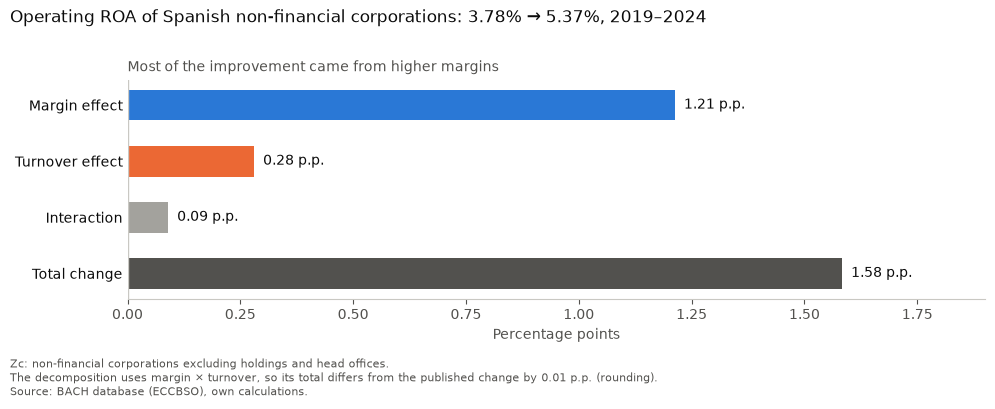

In [56]:
# Figure 1: decomposition of the change in operating ROA, whole economy (Zc)
zc = total_2019.loc['Zc']
parts = ['Margin effect', 'Turnover effect', 'Interaction', 'Total change']
values = [zc['margin_effect'], zc['turnover_effect'], zc['interaction'], zc['d_oroa']]
colors = ['#2a78d6', '#eb6834', '#a3a29d', '#52514e']

fig, ax = plt.subplots(figsize=(10, 4))
y = list(range(len(parts)))[::-1]
ax.barh(y, values, height=0.55, color=colors)
for yi, v in zip(y, values):
    ax.text(v + 0.02, yi, f'{v:.2f} p.p.', va='center', fontsize=10, color='#0b0b0b')

ax.set_yticks(y)
ax.set_yticklabels(parts, fontsize=10, color='#0b0b0b')
ax.axvline(0, color='#c9c8c3', linewidth=1)
ax.set_xlim(0, max(values) * 1.2)
ax.set_xlabel('Percentage points', color='#52514e')
ax.tick_params(axis='x', colors='#52514e')
ax.tick_params(axis='y', length=0)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color('#c9c8c3')

oroa_start = dupont_total.loc[('Zc', 2019), 'oroa']
oroa_end = dupont_total.loc[('Zc', 2024), 'oroa']
fig.suptitle(f'Operating ROA of Spanish non-financial corporations: {oroa_start:.2f}% → {oroa_end:.2f}%, 2019–2024',
             x=0.01, ha='left', fontsize=12, color='#0b0b0b')
ax.set_title('Most of the improvement came from higher margins', loc='left', fontsize=10, color='#52514e')
fig.text(0.01, 0.015,
         'Zc: non-financial corporations excluding holdings and head offices.\n'
         'The decomposition uses margin × turnover, so its total differs from the published change by 0.01 p.p. (rounding).\n'
         'Source: BACH database (ECCBSO), own calculations.',
         fontsize=8, color='#52514e')
plt.tight_layout(rect=(0, 0.11, 1, 0.97))
fig.savefig('../figures/fig1_whole_economy.png', dpi=150)
plt.show()

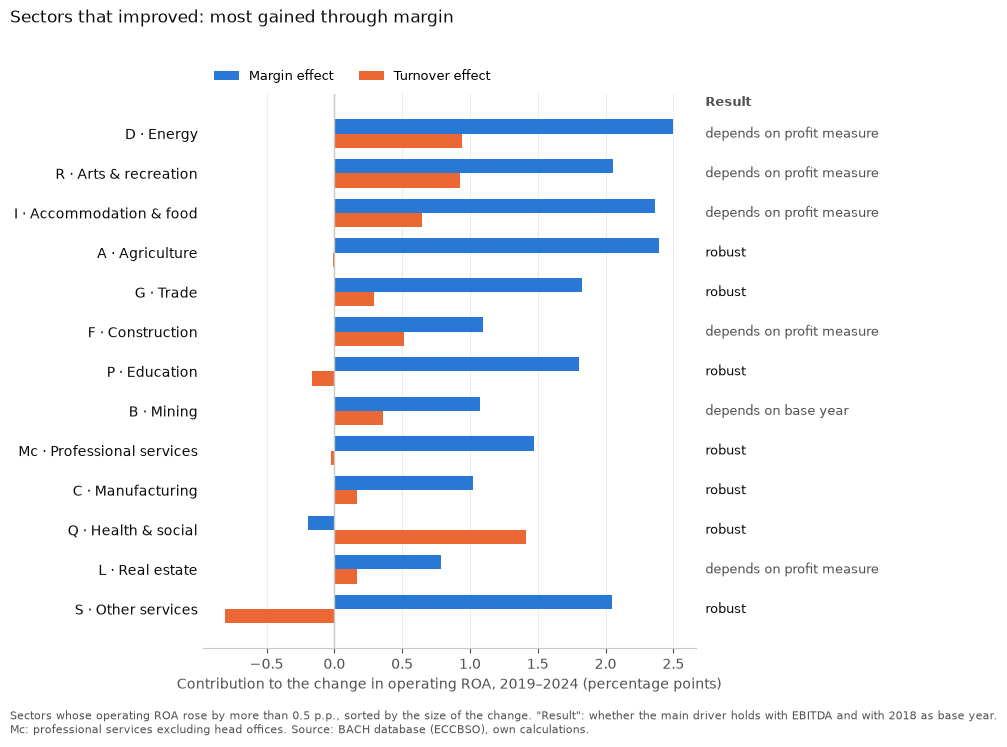

In [57]:
# Figure 2: margin vs turnover effect for the sectors that improved
up_sectors = decomposition_2019[decomposition_2019['trend'] == 'up'].sort_values('d_oroa')

def robustness(sector):
    if not profit_check.loc[sector, 'same_driver']:
        return 'depends on profit measure'
    if not (comparison.loc[sector, 'same_driver'] and comparison.loc[sector, 'same_trend']):
        return 'depends on base year'
    return 'robust'

fig, ax = plt.subplots(figsize=(11, 7.5))
y = np.arange(len(up_sectors))
h = 0.36
ax.barh(y + h / 2, up_sectors['margin_effect'], height=h, color='#2a78d6', label='Margin effect')
ax.barh(y - h / 2, up_sectors['turnover_effect'], height=h, color='#eb6834', label='Turnover effect')
ax.axvline(0, color='#c9c8c3', linewidth=1)

ax.set_yticks(y)
ax.set_yticklabels([f'{s} · {section_names[s]}' for s in up_sectors.index], fontsize=10, color='#0b0b0b')

# Robustness column, outside the plotting area
for yi, s in zip(y, up_sectors.index):
    label = robustness(s)
    ax.text(1.02, yi, label, transform=ax.get_yaxis_transform(), va='center', fontsize=9,
            color='#0b0b0b' if label == 'robust' else '#52514e', clip_on=False)
ax.text(1.02, len(y) - 0.3, 'Result', transform=ax.get_yaxis_transform(), fontsize=9,
        color='#52514e', fontweight='bold', clip_on=False)

ax.set_xlabel('Contribution to the change in operating ROA, 2019–2024 (percentage points)', color='#52514e')
ax.tick_params(axis='x', colors='#52514e')
ax.tick_params(axis='y', length=0)
ax.grid(axis='x', color='#ecebe7', linewidth=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color('#c9c8c3')

fig.suptitle('Sectors that improved: most gained through margin', x=0.01, ha='left', fontsize=12, color='#0b0b0b')
ax.legend(frameon=False, loc='lower left', bbox_to_anchor=(0, 1.0), ncol=2, fontsize=9)
fig.text(0.01, 0.015,
         'Sectors whose operating ROA rose by more than 0.5 p.p., sorted by the size of the change. '
         '"Result": whether the main driver holds with EBITDA and with 2018 as base year.\n'
         'Mc: professional services excluding head offices. Source: BACH database (ECCBSO), own calculations.',
         fontsize=8, color='#52514e')
plt.tight_layout(rect=(0, 0.05, 0.82, 0.97))
fig.savefig('../figures/fig2_sectors.png', dpi=150)
plt.show()